<div class="alert alert-block alert-success">
  <h3><center>MSDS-462: Computer Vision</center></h3>
  <h2><center>Brain Tumor Classification with Human-Readable MRI Explanations Using Deep Learning</center></h2>
  <h3><center>VLM Explanation Evaluation</center></h3>
</div>

<div class="alert alert-block alert-info">
    <h2>1. Imports & Configuration</h2>
</div>

In [5]:
import os
import random
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

sns.set(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [6]:
API_URL = "http://127.0.0.1:8000/predict"
TEST_DIR = Path("../mri_dataset/Testing")
SAMPLES_PER_CLASS = 5
OUTPUT_CSV = "vlm_evaluation_results.csv"

CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]

print(f"API endpoint : {API_URL}")
print(f"Test directory: {TEST_DIR.resolve()}")
print(f"Samples/class : {SAMPLES_PER_CLASS}")
print(f"Output CSV    : {OUTPUT_CSV}")

API endpoint : http://127.0.0.1:8000/predict
Test directory: /Users/mathuria/Desktop/MSDS462_Capstone_Project/mri_dataset/Testing
Samples/class : 5
Output CSV    : vlm_evaluation_results.csv


<div class="alert alert-block alert-info">
    <h2>2. Sample Test Images</h2>
</div>

In [7]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

sampled_images = []

for cls in CLASS_NAMES:
    cls_dir = TEST_DIR / cls
    if not cls_dir.exists():
        print(f"WARNING: class directory not found: {cls_dir}")
        continue

    all_images = sorted(
        f for f in cls_dir.iterdir()
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
    )
    chosen = random.sample(all_images, min(SAMPLES_PER_CLASS, len(all_images)))

    for img_path in chosen:
        sampled_images.append({"image_path": str(img_path), "original_class": cls})

    print(f"{cls:>12s}: {len(all_images):>4d} total, {len(chosen)} sampled")

print(f"\nTotal sampled images: {len(sampled_images)}")

      glioma:  400 total, 5 sampled
  meningioma:  400 total, 5 sampled
     notumor:  400 total, 5 sampled
   pituitary:  400 total, 5 sampled

Total sampled images: 20


<div class="alert alert-block alert-info">
    <h2>3. Call Predict API & Collect Results</h2>
</div>

In [8]:
health = requests.get(API_URL.replace("/predict", "/health"), timeout=10)
print("Backend health:", health.json())

Backend health: {'device': {'cnn_device': 'mps', 'cuda_available': False, 'mps_available': True, 'selected_device': 'mps', 'vlm_device': 'mps'}, 'model_init_error': None, 'models_ready': True, 'status': 'ok'}


In [9]:
results = []

for entry in tqdm(sampled_images, desc="Predicting"):
    img_path = entry["image_path"]
    original_class = entry["original_class"]
    image_name = os.path.basename(img_path)

    try:
        with open(img_path, "rb") as f:
            resp = requests.post(
                API_URL,
                files={"file": (image_name, f, "image/jpeg")},
                timeout=120,
            )
        resp.raise_for_status()
        data = resp.json()

        results.append({
            "image_name": image_name,
            "original_class": original_class,
            "predicted_class": data["prediction"],
            "confidence": data["confidence"],
            "vlm_explanation": data["explanation"],
        })
    except Exception as exc:
        print(f"FAILED {image_name}: {exc}")
        results.append({
            "image_name": image_name,
            "original_class": original_class,
            "predicted_class": "ERROR",
            "confidence": None,
            "vlm_explanation": str(exc),
        })

df = pd.DataFrame(results)
df.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved {len(df)} results to {OUTPUT_CSV}")
df.head()

Predicting: 100%|██████████| 20/20 [02:49<00:00,  8.49s/it]


Saved 20 results to vlm_evaluation_results.csv


,image_name,original_class,predicted_class,confidence,vlm_explanation
0,Te-gl_394.jpg,glioma,glioma,0.996643,The image shows several findings that support ...
1,Te-gl_150.jpg,glioma,glioma,0.999238,The image shows several findings that support ...
2,Te-gl_11.jpg,glioma,glioma,0.995992,The image shows several findings that support ...
3,Te-gl_80.jpg,glioma,glioma,0.998487,The image shows several findings that support ...
4,Te-gl_225.jpg,glioma,glioma,0.998972,The MRI image shows several findings that supp...


<div class="alert alert-block alert-info">
    <h2>4. Load Results & Preview</h2>
</div>

In [10]:
df = pd.read_csv(OUTPUT_CSV)
print(f"Loaded {len(df)} rows from {OUTPUT_CSV}")
df.head(20)

Loaded 20 rows from vlm_evaluation_results.csv


,image_name,original_class,predicted_class,confidence,vlm_explanation
0,Te-gl_394.jpg,glioma,glioma,0.996643,The image shows several findings that support ...
1,Te-gl_150.jpg,glioma,glioma,0.999238,The image shows several findings that support ...
2,Te-gl_11.jpg,glioma,glioma,0.995992,The image shows several findings that support ...
3,Te-gl_80.jpg,glioma,glioma,0.998487,The image shows several findings that support ...
4,Te-gl_225.jpg,glioma,glioma,0.998972,The MRI image shows several findings that supp...
5,Te-me_119.jpg,meningioma,meningioma,0.993183,The image shows several findings that support ...
6,Te-me_109.jpg,meningioma,meningioma,0.985238,The image shows several findings that support ...
7,Te-aug-me_70.jpg,meningioma,meningioma,0.998341,The image shows several findings that support ...
8,Te-me_79.jpg,meningioma,meningioma,0.995145,The image shows several findings that support ...
9,Te-aug-me_53.jpg,meningioma,meningioma,0.999933,The image shows several findings that support ...


<div class="alert alert-block alert-info">
    <h2>5. Explanation Quality Metrics</h2>
</div>

### 5.1 Classification Accuracy (CNN Baseline)

In [12]:
valid = df[df["predicted_class"] != "ERROR"].copy()
total = len(valid)
correct = (valid["original_class"] == valid["predicted_class"]).sum()
accuracy = correct / total if total > 0 else 0

print(f"Classification accuracy: {correct}/{total} = {accuracy:.2%}")

valid["is_correct"] = valid["original_class"] == valid["predicted_class"]
per_class_acc = valid.groupby("original_class")["is_correct"].mean().rename("accuracy")
print("\nPer-class accuracy:")
print(per_class_acc.to_string())

Classification accuracy: 20/20 = 100.00%

Per-class accuracy:
original_class
glioma        1.0
meningioma    1.0
notumor       1.0
pituitary     1.0


### 5.2 Positive Hit Rate (Explanation mentions the predicted class)

In [13]:
KEYWORD_MAP = {
    "glioma": ["glioma"],
    "meningioma": ["meningioma"],
    "notumor": ["no tumor", "normal", "no abnormal", "no visible", "no evidence"],
    "pituitary": ["pituitary"],
}


def explanation_mentions_class(row):
    explanation = str(row["vlm_explanation"]).lower()
    pred = row["predicted_class"]
    keywords = KEYWORD_MAP.get(pred, [pred.lower()])
    return any(kw in explanation for kw in keywords)


valid["hit"] = valid.apply(explanation_mentions_class, axis=1)

overall_hit_rate = valid["hit"].mean()
print(f"Overall positive hit rate: {overall_hit_rate:.2%}")

per_class_hit = valid.groupby("predicted_class")["hit"].mean().rename("hit_rate")
print("\nPer-class positive hit rate:")
print(per_class_hit.to_string())

Overall positive hit rate: 100.00%

Per-class positive hit rate:
predicted_class
glioma        1.0
meningioma    1.0
notumor       1.0
pituitary     1.0


### 5.3 Answer Relevance (Explanation references medical/anatomical terms)

In [14]:
MEDICAL_TERMS = [
    "mass", "lesion", "tumor", "enhancement", "edema", "midline",
    "shift", "ventricle", "cortex", "frontal", "temporal", "parietal",
    "occipital", "sella", "sellar", "suprasellar", "dura", "meninges",
    "contrast", "heterogeneous", "homogeneous", "cystic", "necrosis",
    "calcification", "hyperintense", "hypointense", "flair",
    "t1", "t2", "mri", "brain", "cerebral", "region", "abnormal",
    "diagnosis", "finding", "tissue", "signal", "sphenoid",
]


def count_medical_terms(text):
    text_lower = str(text).lower()
    return sum(1 for term in MEDICAL_TERMS if term in text_lower)


valid["medical_term_count"] = valid["vlm_explanation"].apply(count_medical_terms)
valid["has_medical_terms"] = valid["medical_term_count"] > 0

relevance_rate = valid["has_medical_terms"].mean()
avg_terms = valid["medical_term_count"].mean()

print(f"Answer relevance (has medical terms): {relevance_rate:.2%}")
print(f"Avg medical terms per explanation   : {avg_terms:.1f}")

per_class_terms = (
    valid.groupby("original_class")["medical_term_count"]
    .mean()
    .rename("avg_medical_terms")
)
print("\nPer-class avg medical terms:")
print(per_class_terms.to_string())

Answer relevance (has medical terms): 100.00%
Avg medical terms per explanation   : 8.0

Per-class avg medical terms:
original_class
glioma        8.6
meningioma    9.6
notumor       7.8
pituitary     5.8


### 5.4 Average Answer Length

In [15]:
valid["char_length"] = valid["vlm_explanation"].str.len()
valid["word_count"] = valid["vlm_explanation"].str.split().str.len()
valid["sentence_count"] = valid["vlm_explanation"].str.count(r"[.!?]+")

print("=== Answer Length Statistics ===")
print(f"Avg character length : {valid['char_length'].mean():.0f}")
print(f"Avg word count       : {valid['word_count'].mean():.1f}")
print(f"Avg sentence count   : {valid['sentence_count'].mean():.1f}")
print()

length_stats = (
    valid.groupby("original_class")[["char_length", "word_count", "sentence_count"]]
    .mean()
    .round(1)
)
print("Per-class length stats:")
length_stats

=== Answer Length Statistics ===
Avg character length : 413
Avg word count       : 66.8
Avg sentence count   : 3.9

Per-class length stats:


,char_length,word_count,sentence_count
original_class,,,
glioma,493.0,79.4,4.6
meningioma,505.8,83.4,4.4
notumor,319.8,51.2,3.4
pituitary,333.8,53.2,3.0


### 5.5 Explanation Consistency (correct vs incorrect predictions)

In [16]:
valid["is_correct"] = valid["original_class"] == valid["predicted_class"]

consistency = (
    valid.groupby("is_correct")
    .agg(
        count=("image_name", "size"),
        avg_confidence=("confidence", "mean"),
        avg_word_count=("word_count", "mean"),
        avg_medical_terms=("medical_term_count", "mean"),
        hit_rate=("hit", "mean"),
    )
    .round(2)
)
consistency.index = consistency.index.map({True: "Correct", False: "Incorrect"})
print("Explanation quality by prediction correctness:")
consistency

Explanation quality by prediction correctness:


,count,avg_confidence,avg_word_count,avg_medical_terms,hit_rate
is_correct,,,,,
Correct,20,1.0,66.8,7.95,1.0


<div class="alert alert-block alert-info">
    <h2>6. Summary Dashboard</h2>
</div>

In [17]:
summary = pd.DataFrame({
    "Metric": [
        "Total images evaluated",
        "Classification accuracy",
        "Positive hit rate",
        "Answer relevance (has medical terms)",
        "Avg medical terms per explanation",
        "Avg word count",
        "Avg sentence count",
        "Avg confidence",
    ],
    "Value": [
        f"{total}",
        f"{accuracy:.2%}",
        f"{overall_hit_rate:.2%}",
        f"{relevance_rate:.2%}",
        f"{avg_terms:.1f}",
        f"{valid['word_count'].mean():.1f}",
        f"{valid['sentence_count'].mean():.1f}",
        f"{valid['confidence'].mean():.4f}",
    ],
})

print("=" * 55)
print("         VLM EXPLANATION QUALITY SUMMARY")
print("=" * 55)
for _, row in summary.iterrows():
    print(f"{row['Metric']:<42s} {row['Value']:>10s}")
print("=" * 55)

         VLM EXPLANATION QUALITY SUMMARY
Total images evaluated                             20
Classification accuracy                       100.00%
Positive hit rate                             100.00%
Answer relevance (has medical terms)          100.00%
Avg medical terms per explanation                 8.0
Avg word count                                   66.8
Avg sentence count                                3.9
Avg confidence                                 0.9960


<div class="alert alert-block alert-info">
    <h2>7. Visualizations</h2>
</div>

/var/folders/rw/27srsg3n0m3fwy297z_pw4c80000gn/T/ipykernel_75916/962772148.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid, x="original_class", y="word_count", ax=axes[1, 0], palette="Set2")
/var/folders/rw/27srsg3n0m3fwy297z_pw4c80000gn/T/ipykernel_75916/962772148.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid, x="original_class", y="medical_term_count", ax=axes[1, 1], palette="Set3")


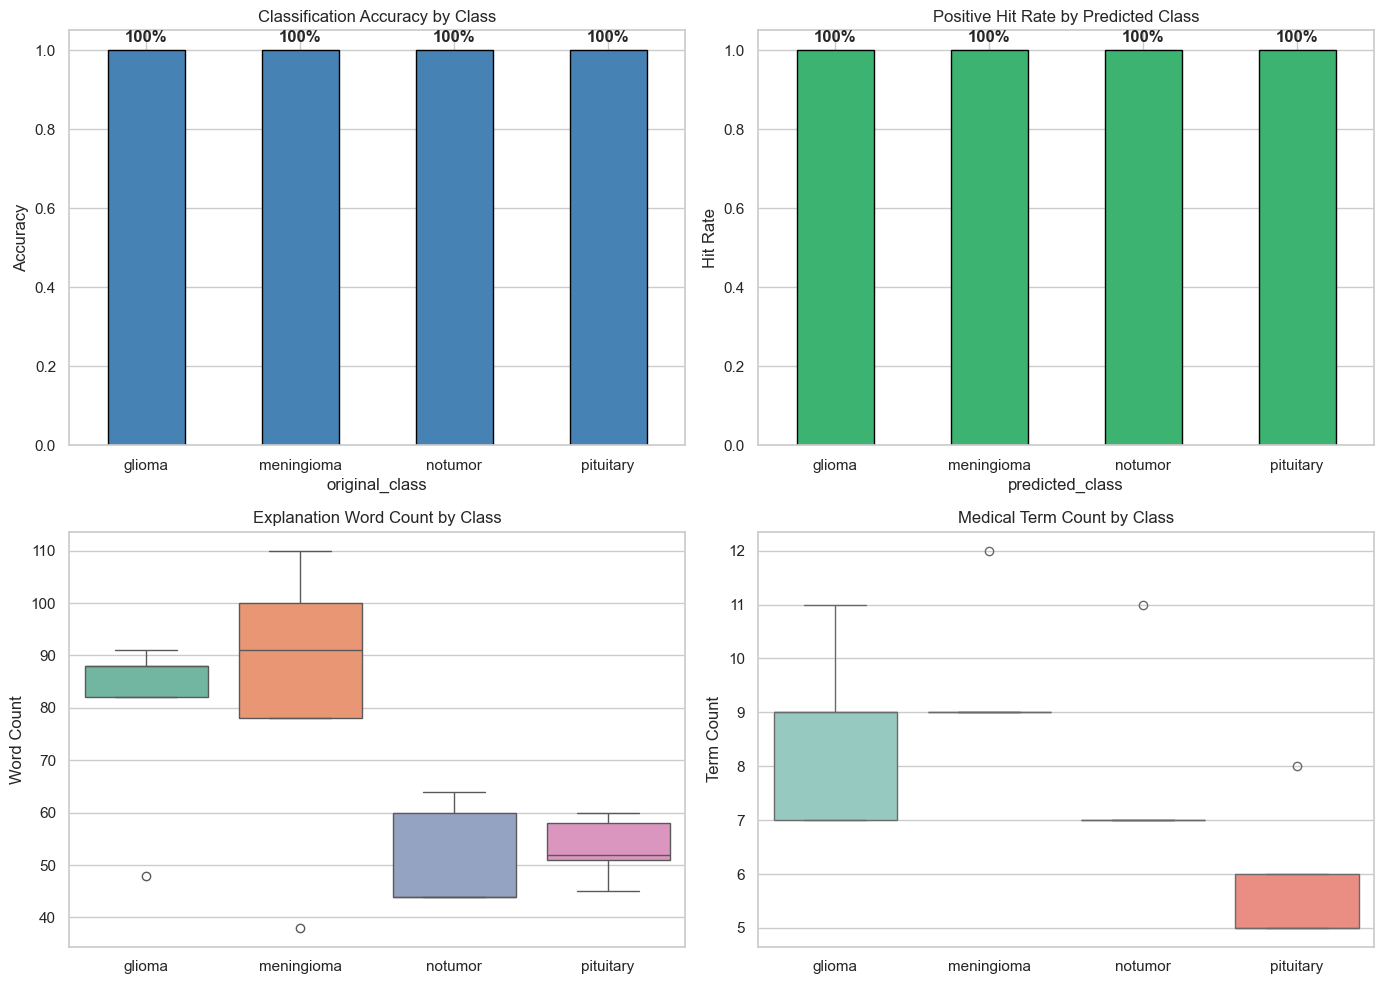

Plots saved to vlm_evaluation_plots.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Per-class accuracy
per_class_acc.plot.bar(ax=axes[0, 0], color="steelblue", edgecolor="black")
axes[0, 0].set_title("Classification Accuracy by Class")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].tick_params(axis="x", rotation=0)
for i, v in enumerate(per_class_acc.values):
    axes[0, 0].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# (b) Per-class hit rate
per_class_hit.plot.bar(ax=axes[0, 1], color="mediumseagreen", edgecolor="black")
axes[0, 1].set_title("Positive Hit Rate by Predicted Class")
axes[0, 1].set_ylabel("Hit Rate")
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].tick_params(axis="x", rotation=0)
for i, v in enumerate(per_class_hit.values):
    axes[0, 1].text(i, v + 0.02, f"{v:.0%}", ha="center", fontweight="bold")

# (c) Word count distribution
sns.boxplot(data=valid, x="original_class", y="word_count", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Explanation Word Count by Class")
axes[1, 0].set_ylabel("Word Count")
axes[1, 0].set_xlabel("")

# (d) Medical term count distribution
sns.boxplot(data=valid, x="original_class", y="medical_term_count", ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("Medical Term Count by Class")
axes[1, 1].set_ylabel("Term Count")
axes[1, 1].set_xlabel("")

plt.tight_layout()
plt.savefig("vlm_evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plots saved to vlm_evaluation_plots.png")